# LeetCode #109: Convert Sorted List to Binary Search Tree

https://leetcode.com/problems/convert-sorted-list-to-binary-search-tree/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Convert list to array | O(n) | O(n) | Extra space for array, then use #108 |
| **Slow/Fast pointer (in-place) ★** | **O(n log n)** | **O(log n)** | Find mid in-place, split list, recurse |

---

## Understanding the Methods

### Brute Force (Convert to Array)
Copy all list values to an array. Then apply the same divide-and-conquer as #108. Simple but uses O(n) extra space.

### Slow/Fast Pointer (Optimal for Space ★)
Use slow/fast pointer to find middle node. Track `prev` to disconnect the left half (`prev.next = null`). Build root from `slow`. Recurse on the two halves. O(n log n) time but only O(log n) stack space.

## Constraints
- List length: [0, 2×10⁴]
- Node values: [-10⁵, 10⁵]
- Guaranteed sorted in ascending order

## Solutions

### C#

In [ ]:
public class Solution {
    public TreeNode SortedListToBST(ListNode head) {
        if (head == null)       return null;
        if (head.next == null)  return new TreeNode(head.val);

        ListNode prev = null, slow = head, fast = head;
        while (fast != null && fast.next != null) {
            prev = slow;
            slow = slow.next;
            fast = fast.next.next;
        }
        prev.next = null;  // cut left half

        var node    = new TreeNode(slow.val);
        node.left   = SortedListToBST(head);
        node.right  = SortedListToBST(slow.next);
        return node;
    }
}

### Python

In [ ]:
class Solution:
    def sortedListToBST(self, head):
        if not head:            return None
        if not head.next:       return TreeNode(head.val)

        prev, slow, fast = None, head, head
        while fast and fast.next:
            prev = slow
            slow = slow.next
            fast = fast.next.next
        prev.next = None  # cut

        node       = TreeNode(slow.val)
        node.left  = self.sortedListToBST(head)
        node.right = self.sortedListToBST(slow.next)
        return node

### Go

In [ ]:
func sortedListToBST(head *ListNode) *TreeNode {
    if head == nil       { return nil }
    if head.Next == nil  { return &TreeNode{Val: head.Val} }

    var prev *ListNode
    slow, fast := head, head
    for fast != nil && fast.Next != nil {
        prev = slow
        slow = slow.Next
        fast = fast.Next.Next
    }
    prev.Next = nil  // cut

    node        := &TreeNode{Val: slow.Val}
    node.Left    = sortedListToBST(head)
    node.Right   = sortedListToBST(slow.Next)
    return node
}

### Rust

In [ ]:
// Rust: convert to vec for simplicity (slow/fast on Box<ListNode> is complex)
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn sorted_list_to_bst(head: Option<Box<ListNode>>) -> Option<Rc<RefCell<TreeNode>>> {
        let mut vals = vec![];
        let mut cur  = head.as_ref();
        while let Some(node) = cur {
            vals.push(node.val);
            cur = node.next.as_ref();
        }

        fn build(vals: &[i32]) -> Option<Rc<RefCell<TreeNode>>> {
            if vals.is_empty() { return None; }
            let mid  = vals.len() / 2;
            let node = Rc::new(RefCell::new(TreeNode::new(vals[mid])));
            node.borrow_mut().left  = build(&vals[..mid]);
            node.borrow_mut().right = build(&vals[mid+1..]);
            Some(node)
        }
        build(&vals)
    }
}

## Example Scenarios

### 1. Common Case — 5 Nodes
**Input:** `head = -10 → -3 → 0 → 5 → 9`

Slow/fast finds mid = 0 (node 3). Cut at prev (-3): left half = [-10,-3], right = [5,9]. Root = 0. Recurse each half. Left mid = -10, right child = -3. Right mid = 5, right child = 9.

WHY: Odd-length list. Slow pointer lands squarely on the middle. The prev pointer correctly cuts the list in two. Standard baseline for slow/fast.

**Output:** `[0, -10, 5, null, -3, null, 9]`

---

### 2. Slightly Complex — Even-Length List (6 nodes)
**Input:** `head = 1 → 2 → 3 → 4 → 5 → 6`

Slow/fast: when fast reaches end, slow=4. Cut at 3: left=[1,2,3], right=[5,6]. Root=4. Left recurse finds mid=2. Right recurse finds mid=5. Asymmetric: left=3 vs right=2.

WHY: Even-length creates asymmetric split. The slow pointer ends past center, giving left=3 and right=2 nodes. Tests off-center splits.

**Output:** `[4, 2, 5, 1, 3, null, 6]` (one valid answer)

---

### 3. Edge Case: Time Factor — 20,000-Node List (Max Input)
**Input:** `head = 1 → 2 → ... → 20000`

Finding mid takes $O(n/2)$ pointer traversals (no random access). After split, each half is ~10,000 nodes. Recursion depth = $\log_2(20000) \approx 15$. Total traversals across all levels = $O(n \log n)$.

WHY: $O(n \log n)$ time, NOT $O(n)$! Finding mid costs $O(n/2)$ each time (linked list, no random access). With ~15 recursion levels and $O(n)$ work per level: $O(n \log n) \approx 300{,}000$ ops.

**Output:** balanced BST of depth ~15

---

### 4. Edge Case: Space Factor — No Array Copy, Stack Only
**Input:** Sorted list of 20,000 nodes

No auxiliary array (unlike brute force). Space = $O(\log n)$ for recursion = ~15 frames. Each frame stores 3 pointers (head, slow, fast). The list is split in-place.

WHY: Space is $O(\log n)$ vs $O(n)$ for array-copy. Trade-off: $O(n \log n)$ time but $O(\log n)$ space. The follow-up: "can you do $O(n)$ time AND $O(\log n)$ space?" (Yes, with inorder simulation.)

**Output:** Stack: $O(\log n) \approx 15$ frames

---

### 5. Almost-Impossible but Plausible — Two-Node List at Boundaries
**Input:** `head = -100000 → 100000`

Slow/fast: after one iteration, fast.next=null, loop ends. Slow=100000, prev=-100000. Cut: left=[-100000], root=100000, right=null. Left recurse: single node -100000.

WHY: Minimum non-trivial list ($n = 2$) with values at constraint boundaries $[-10^5, 10^5]$. The slow pointer advances once, making the second node root. Off-by-one in slow/fast gives wrong root. Extreme values test for overflow.

**Output:** `[100000, -100000]`

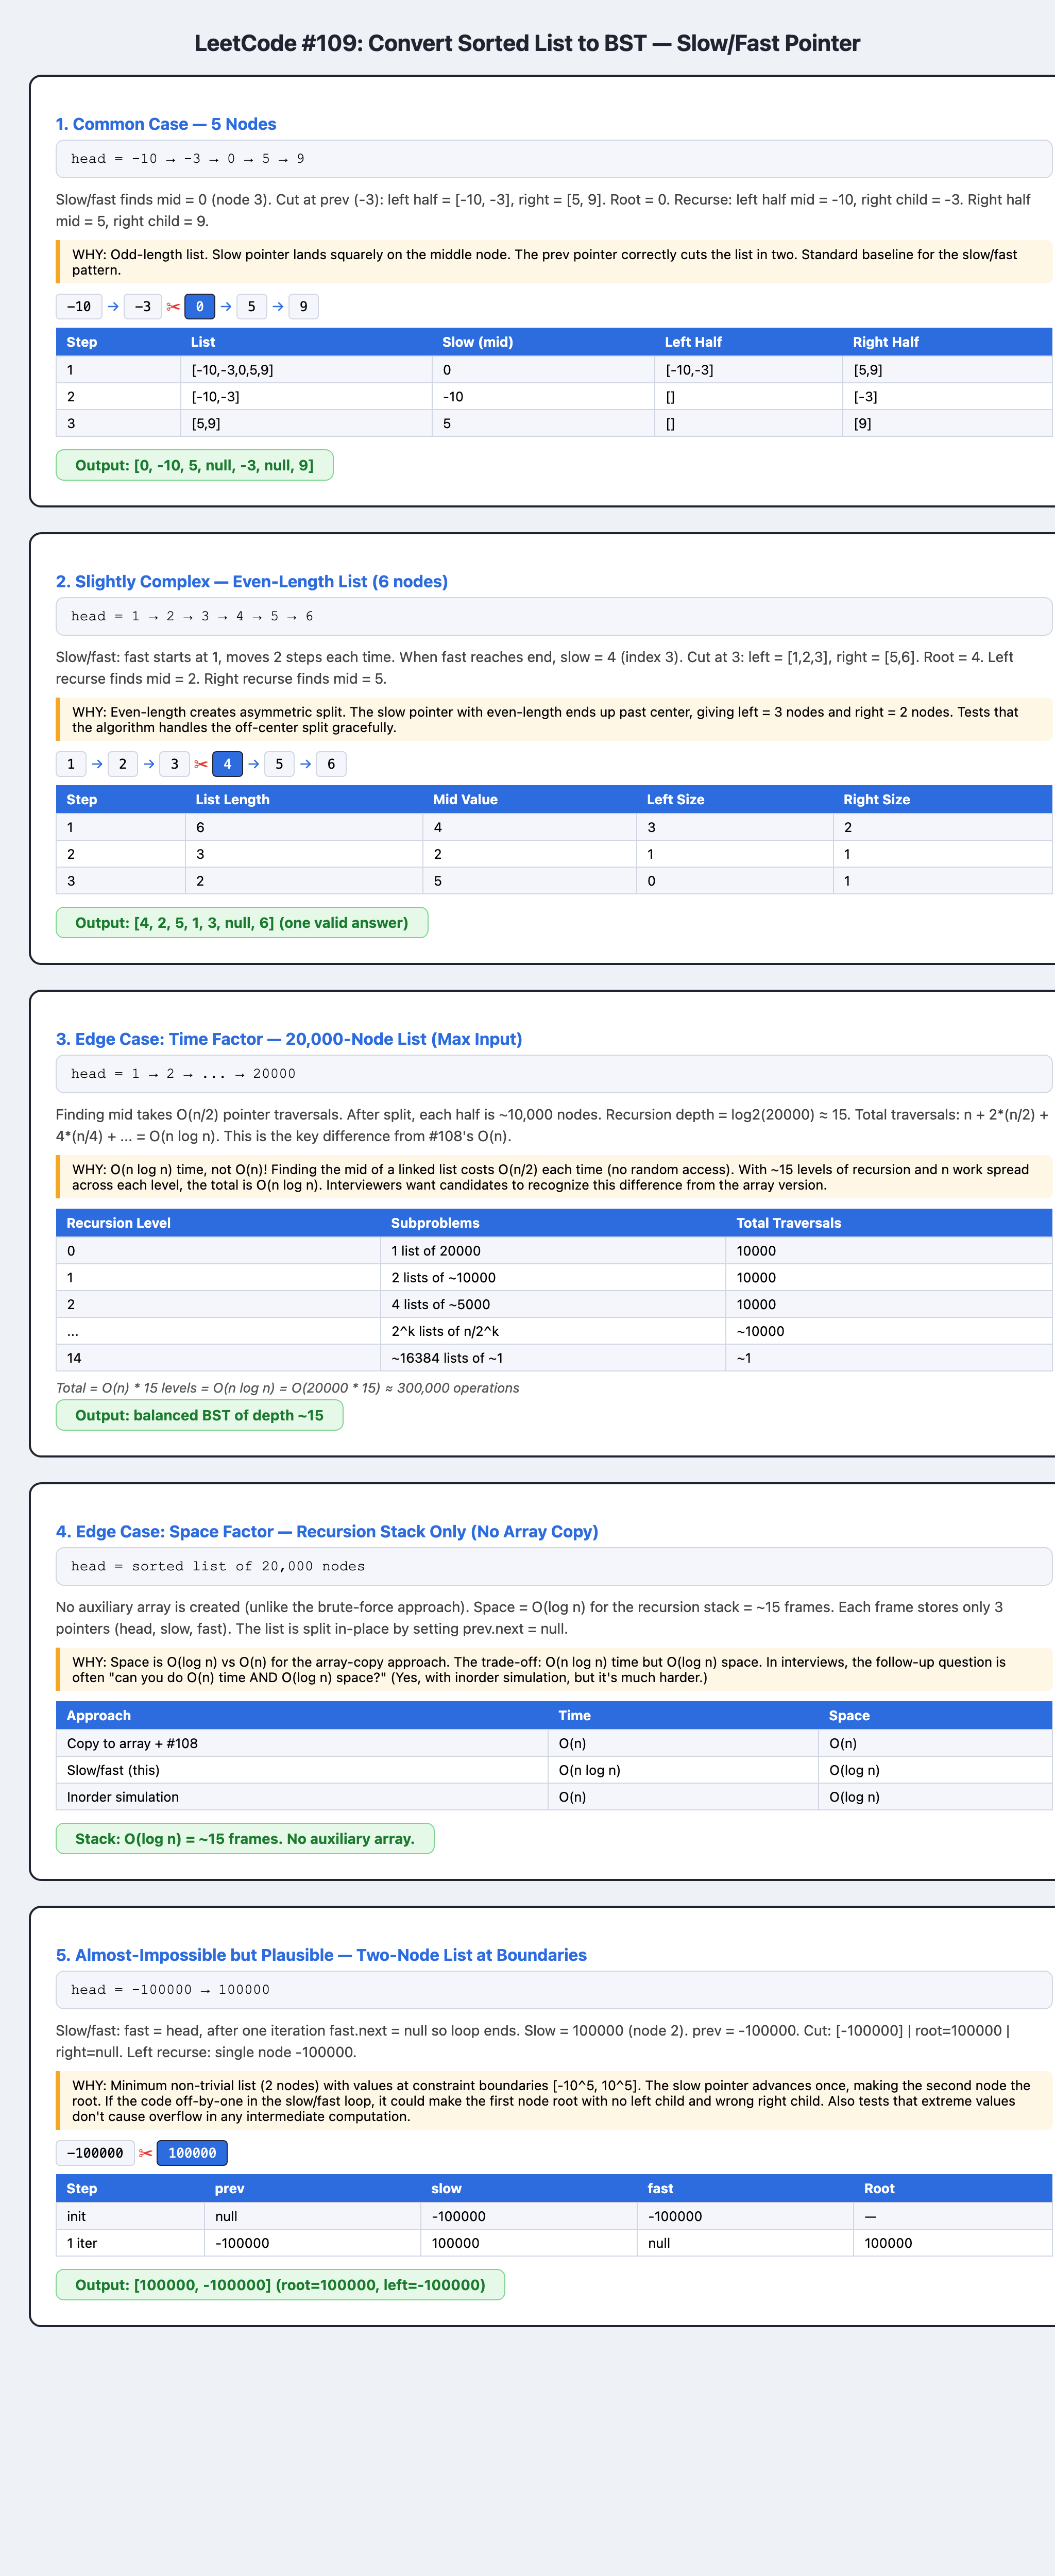